In [2]:
import pandas as pd
df = pd.read_csv("../data/tickets.csv")
print(df.shape)             
# (rows, columns)
print(df.columns.tolist())
df.head()

(28587, 16)
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [3]:
df = df[df["language"] == "en"].copy()
df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")
df = df[["text", "queue"]].dropna().drop_duplicates()
df = df[df["text"].str.strip().str.len() > 10]   # drop near-empty tickets
print(df.shape)

(16338, 2)


queue
Technical Support                  4737
Product Support                    3073
Customer Service                   2410
IT Support                         1942
Billing and Payments               1595
Returns and Exchanges               820
Service Outages and Maintenance     664
Sales and Pre-Sales                 513
Human Resources                     348
General Inquiry                     236
Name: count, dtype: int64


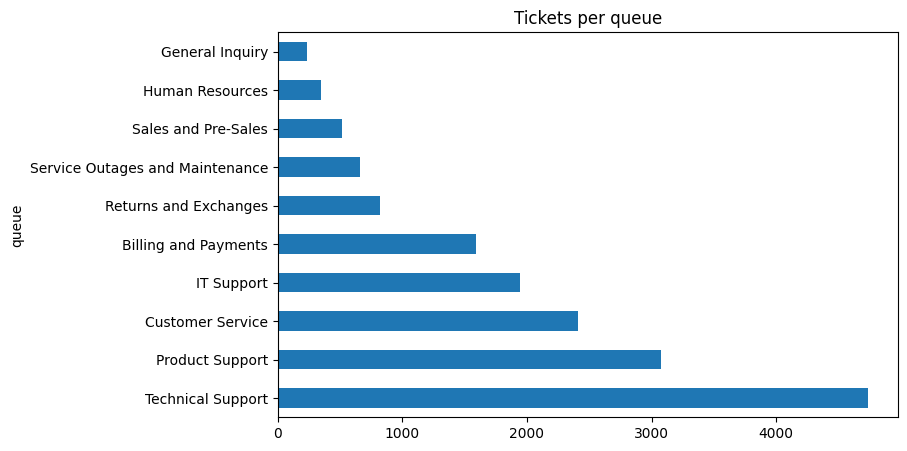

In [4]:
import matplotlib.pyplot as plt
counts = df["queue"].value_counts()
print(counts)
counts.plot(kind="barh", figsize=(8, 5), title="Tickets per queue"); 
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
keep = counts[counts >= 50].index
df = df[df["queue"].isin(keep)]
X_train, X_test, y_train, y_test = train_test_split(
df["text"], df["queue"], test_size=0.2, stratify=df["queue"], 
random_state=42)
print(len(X_train), len(X_test))

13070 3268


In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print("Baseline macro-F1:", f1_score(y_test, dummy.predict(X_test), 
average="macro"))

Baseline macro-F1: 0.044934756820877816


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report,f1_score
models = {
"LogisticRegression": LogisticRegression(max_iter=1000, 
class_weight="balanced"),
"NaiveBayes": MultinomialNB(),
"LinearSVC": LinearSVC(class_weight="balanced"),
}
results, pipes = {}, {}
for name, clf in models.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), 
min_df=2)),
        ("clf", clf),
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results[name] = f1_score(y_test, pred, average="macro")
    pipes[name] = pipe
    print(f"\n=== {name} ===\n", classification_report(y_test, pred))
pd.Series(results).sort_values(ascending=False)


=== LogisticRegression ===
                                  precision    recall  f1-score   support

           Billing and Payments       0.83      0.76      0.79       319
               Customer Service       0.47      0.49      0.48       482
                General Inquiry       0.65      0.66      0.65        47
                Human Resources       0.57      0.66      0.61        70
                     IT Support       0.45      0.54      0.49       388
                Product Support       0.53      0.47      0.50       615
          Returns and Exchanges       0.48      0.54      0.51       164
            Sales and Pre-Sales       0.38      0.68      0.49       103
Service Outages and Maintenance       0.56      0.80      0.66       133
              Technical Support       0.62      0.52      0.57       947

                       accuracy                           0.55      3268
                      macro avg       0.55      0.61      0.57      3268
                   w

c:\Users\Sagar AM\Desktop\ML_pro\ticket_class\ticket-classifier\ticket-classifier\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sagar AM\Desktop\ML_pro\ticket_class\ticket-classifier\ticket-classifier\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sagar AM\Desktop\ML_pro\ticket_class\ticket-classifier\ticket-classifier\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels


=== NaiveBayes ===
                                  precision    recall  f1-score   support

           Billing and Payments       0.94      0.52      0.67       319
               Customer Service       0.40      0.27      0.33       482
                General Inquiry       0.00      0.00      0.00        47
                Human Resources       0.00      0.00      0.00        70
                     IT Support       1.00      0.00      0.01       388
                Product Support       0.42      0.23      0.30       615
          Returns and Exchanges       1.00      0.01      0.01       164
            Sales and Pre-Sales       0.00      0.00      0.00       103
Service Outages and Maintenance       1.00      0.01      0.01       133
              Technical Support       0.36      0.93      0.52       947

                       accuracy                           0.40      3268
                      macro avg       0.51      0.20      0.18      3268
                   weighted 

LinearSVC             0.715332
LogisticRegression    0.574376
NaiveBayes            0.184254
dtype: float64

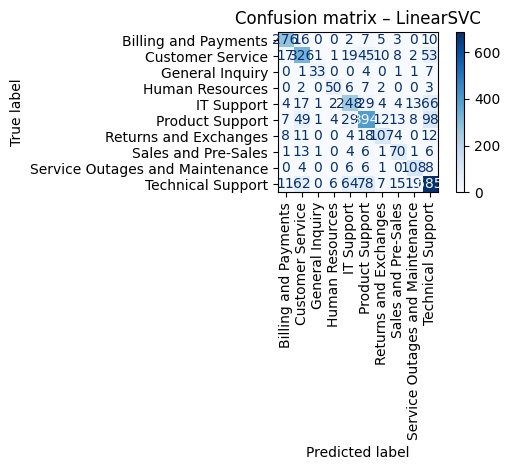

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
best = max(results, key=results.get)
ConfusionMatrixDisplay.from_estimator(pipes[best], X_test, y_test,
xticks_rotation=90, cmap="Blues")
plt.title(f"Confusion matrix – {best}"); plt.tight_layout(); plt.show()

In [9]:
import numpy as np
lr = pipes["LogisticRegression"]
words = lr.named_steps["tfidf"].get_feature_names_out()
for i, cls in enumerate(lr.named_steps["clf"].classes_):
    top = np.argsort(lr.named_steps["clf"].coef_[i])[-8:]
    print(f"{cls}: {', '.join(words[top])}")

Billing and Payments: details, account, charges, invoice, subscription, pricing, payment, billing
Customer Service: brand expansion, datarobot, ineffective, analytics investment, details, integrating, strategies, integration
General Inquiry: overall, analytics possible, security solutions, integration, attempt medical, tools recent, enhance, engagement
Human Resources: php postgresql, secure storage, incident, data compromise, employees, onboarding, hr, employee
IT Support: performance, restarting devices, network, connectivity, restarting, devices, website, digital tools
Product Support: inconsistent, growth, assistance required, campaign metrics, product, firmware, crashes, algorithm
Returns and Exchanges: boosting, supply comprehensive, incorrect, models, investment returns, investment, return, returns
Sales and Pre-Sales: financial, meet, analysis results, insights, client, pricing, solutions, sales
Service Outages and Maintenance: impacting, disruptions, network, disruption, outag

In [10]:
import joblib
joblib.dump(pipes[best], "../models/ticket_classifier.joblib")

['../models/ticket_classifier.joblib']

In [11]:
model = joblib.load("../models/ticket_classifier.joblib")
samples = [
"I was charged twice for my subscription this month",
"The app crashes every time I click export",
"Can you add dark mode to the dashboard?",
]
for s, p in zip(samples, model.predict(samples)):
    print(f"{p:<25} <- {s}")

Billing and Payments      <- I was charged twice for my subscription this month
Product Support           <- The app crashes every time I click export
Technical Support         <- Can you add dark mode to the dashboard?


In [12]:
import joblib

best_model = pipes["LinearSVC"]

joblib.dump(best_model, "../models/ticket_classifier.joblib")

['../models/ticket_classifier.joblib']